<a href="https://colab.research.google.com/github/junioriankoski/trabalho-faculdade/blob/main/Gr%C3%A1ficos_trab_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perguntas de Análise:**
**1.** Quais tipos de acidente geram mais vítimas graves ou fatais?

**2.** Acidentes noturnos são mais graves do que os diurnos?

**3.** Em quais dias da semana e horários ocorrem mais acidentes?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/cat_acidentes.csv', sep=';')

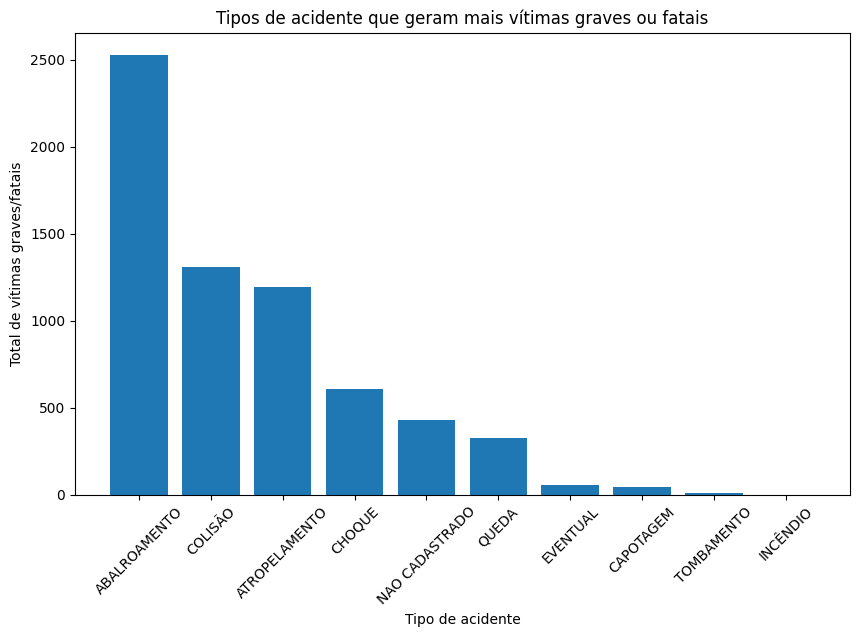

In [3]:
df['grave_fatal'] = (
    df['feridos_gr'].fillna(0)
    + df['fatais'].fillna(0)
    + df['mortes'].fillna(0)
)

resultado = (
    df.groupby('tipo_acid')['grave_fatal']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(resultado.index, resultado.values)

plt.title('Tipos de acidente que geram mais vítimas graves ou fatais')
plt.xlabel('Tipo de acidente')
plt.ylabel('Total de vítimas graves/fatais')

plt.xticks(rotation=45)

plt.show()

# **Interpretação:**

*   Observa-se que os acidentes do tipo ***Abalroamento*** concentram o maior número de vítimas graves ou fatais, seguidos por ***Colisão*** e ***Atropelamento***. Embora nem sempre sejam os acidentes mais letais individualmente, o alto volume de ocorrências faz com que concentrem mais vítimas severas no total analisado.



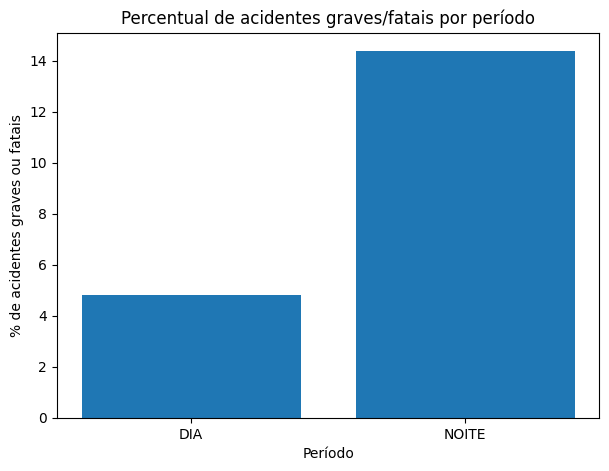

In [4]:
df['grave_ou_fatal'] = (
    (df['feridos_gr'] > 0)
    | (df['fatais'] > 0)
    | (df['mortes'] > 0)
)

gravidade = (
    df.groupby('noite_dia')['grave_ou_fatal']
    .mean()
    * 100
)

plt.figure(figsize=(7,5))

plt.bar(
    gravidade.index,
    gravidade.values
)

plt.title('Percentual de acidentes graves/fatais por período')
plt.xlabel('Período')
plt.ylabel('% de acidentes graves ou fatais')

plt.show()

# **Interpretação:**

*   Os dados indicam que a***cidentes noturnos tendem a ser mais graves do que os diurnos***. Aproximadamente ***14% dos acidentes ocorridos à noite envolveram vítimas graves ou fatais***, enquanto durante o dia esse percentual ficou em torno de 5%. Isso sugere que fatores como menor visibilidade e condições de circulação podem influenciar a severidade.




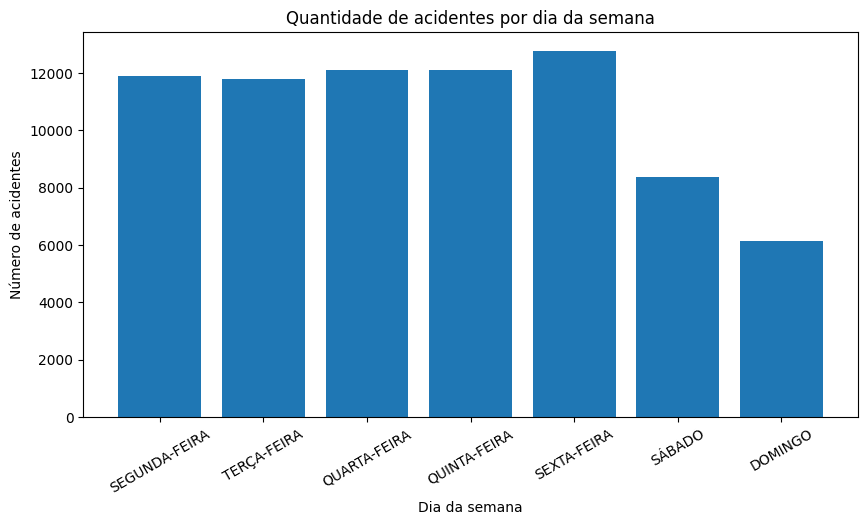

In [5]:
ordem = [
    'SEGUNDA-FEIRA',
    'TERÇA-FEIRA',
    'QUARTA-FEIRA',
    'QUINTA-FEIRA',
    'SEXTA-FEIRA',
    'SÁBADO',
    'DOMINGO'
]

dias = (
    df['dia_sem']
    .value_counts()
    .reindex(ordem)
)

plt.figure(figsize=(10,5))

plt.bar(
    dias.index,
    dias.values
)

plt.title('Quantidade de acidentes por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Número de acidentes')

plt.xticks(rotation=30)

plt.show()

# **Interpretação:**

*   Os acidentes ocorrem com maior frequência nos ***dias úteis***, com destaque para a ***sexta-feira***, que apresentou o maior número de registros. O fim de semana apresenta redução no volume total de ocorrências.



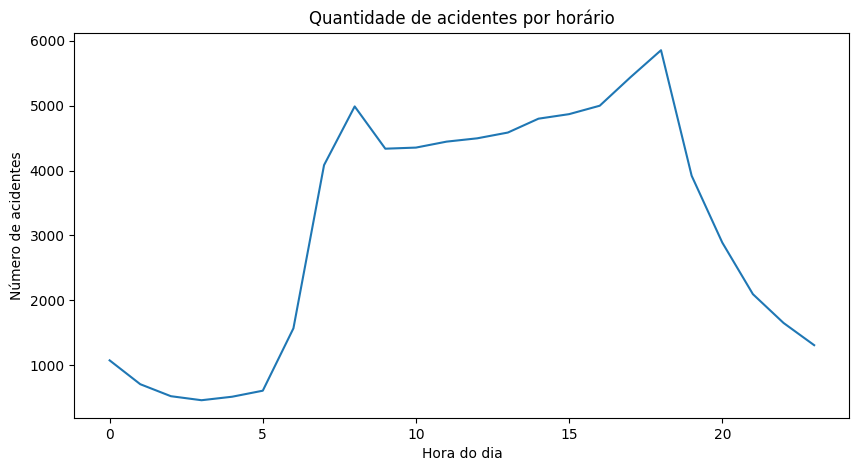

In [6]:
df['hora_num'] = pd.to_datetime(
    df['hora'],
    format='%H:%M:%S.%f',
    errors='coerce'
).dt.hour

horas = (
    df['hora_num']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    horas.index,
    horas.values
)

plt.title('Quantidade de acidentes por horário')
plt.xlabel('Hora do dia')
plt.ylabel('Número de acidentes')

plt.show()

# **Interpretação:**

*   Observa-se aumento gradual das ocorrências ao longo do dia, c***om pico por volta das 18h***, horário associado ao deslocamento de retorno e maior fluxo de veículos. Durante a madrugada os registros diminuem significativamente.

